# Detección de Enfermedades en Plantas con CNNs
### Curso SI3014 — Redes Neuronales y Aprendizaje Profundo

**Autoras:** Mariana Valderrama Castañeda · Sara López Marín · Alexandra Hurtado David

---

En este notebook entrenamos y comparamos tres modelos para clasificar imágenes de hojas de plantas como **sanas** o **enfermas** usando el dataset **PlantVillage**.

| Modelo | Descripción |
|--------|-------------|
| **Modelo 1** | CNN construida desde cero (*baseline*) |
| **Modelo 2** | Misma CNN + más augmentación y regularización |
| **Modelo 3** | ResNet18 con Transfer Learning |


## 0. Instalación de dependencias


In [3]:
# instalacion de librerias necesarias para el proyecto
# torch y torchvision para el entrenamiento de modelos de deep learning
# scikit-learn para metricas de evaluacion (f1, recall, auc)
# matplotlib y seaborn para visualizaciones
# tqdm para barras de progreso
!pip install -q torch torchvision
!pip install -q scikit-learn matplotlib seaborn tqdm kaggle

import torch

# configuramos el dispositivo de computo
# si hay gpu disponible se usa cuda, si no se usa cpu
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# mostramos la configuracion de hardware utilizada en este entrenamiento
print("=" * 50)
print("CONFIGURACIÓN DE HARDWARE")
print("=" * 50)
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU     : No disponible — entrenando en CPU")
print("=" * 50)

CONFIGURACIÓN DE HARDWARE
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 1. Descarga del Dataset

Usamos el dataset **PlantVillage** disponible en Kaggle.
Contiene ~54,000 imágenes de hojas de plantas con 38 clases originales.
Nosotras colapsamos todas las clases en **binario**: `sana` vs `enferma`.

### Requisito previo: configurar credenciales de Kaggle
1. Ve a https://www.kaggle.com → Account → API → *Create New Token*
2. Descarga el archivo `kaggle.json`
3. Súbelo cuando la celda te lo pida


In [4]:
import os
from pathlib import Path

# recorremos el directorio raiz del dataset en kaggle
for root, dirs, files in os.walk("/kaggle/input/datasets/emmarex/plantdisease"):
    level = root.replace("/kaggle/input/datasets/emmarex/plantdisease", "").count(os.sep)
    if level <= 2:
        indent = "  " * level
        # contamos cuantas imagenes hay en la carpeta actual
        n_imgs = len([f for f in files if f.lower().endswith((".jpg",".jpeg",".png"))])
         # mostramos el nombre de la carpeta y la cantidad de imagenes si las hay
        print(f"{indent}{os.path.basename(root)}/  {'→ '+str(n_imgs)+' imágenes' if n_imgs else ''}")

plantdisease/  
  PlantVillage/  
    Pepper__bell___Bacterial_spot/  → 997 imágenes
    Potato___healthy/  → 152 imágenes
    Tomato_Leaf_Mold/  → 952 imágenes
    Tomato__Tomato_YellowLeaf__Curl_Virus/  → 3208 imágenes
    Tomato_Bacterial_spot/  → 2127 imágenes
    Tomato_Septoria_leaf_spot/  → 1771 imágenes
    Tomato_healthy/  → 1591 imágenes
    Tomato_Spider_mites_Two_spotted_spider_mite/  → 1676 imágenes
    Tomato_Early_blight/  → 1000 imágenes
    Tomato__Target_Spot/  → 1404 imágenes
    Pepper__bell___healthy/  → 1478 imágenes
    Potato___Late_blight/  → 1000 imágenes
    Tomato_Late_blight/  → 1909 imágenes
    Potato___Early_blight/  → 1000 imágenes
    Tomato__Tomato_mosaic_virus/  → 373 imágenes
  plantvillage/  
    PlantVillage/  


In [5]:
import os
from pathlib import Path

# ── Rutas para Kaggle (el dataset ya está montado, no hay que descargar) ─────
RAW_DIR    = Path("/kaggle/input/datasets/emmarex/plantdisease")
BINARY_DIR = Path("/kaggle/working/binary")
BINARY_DIR.mkdir(parents=True, exist_ok=True)

# ── Explorar estructura ───────────────────────────────────────────────────────
carpetas = sorted([p.name for p in RAW_DIR.iterdir() if p.is_dir()])
print(f"Total de carpetas encontradas: {len(carpetas)}")
print("Ejemplos:", carpetas[:6])


Total de carpetas encontradas: 2
Ejemplos: ['PlantVillage', 'plantvillage']


## 2. Reorganización Binaria del Dataset

PlantVillage tiene 38 clases. Las colapsamos en 2:
- `sana` ← carpetas que contienen `healthy` en el nombre
- `enferma` ← todas las demás

Usamos el split oficial **60/20/20** con estratificación.


In [6]:
# creamos la estructura de carpetas necesaria para organizar el dataset de forma binaria
for split in ["train", "val", "test"]:
    for clase in ["sana", "enferma"]:
        (BINARY_DIR / split / clase).mkdir(parents=True, exist_ok=True)

#Recopilar todas las imágenes con su etiqueta binaria 
plant_dir = RAW_DIR / "PlantVillage"
all_images = []

for carpeta in plant_dir.iterdir():
    if not carpeta.is_dir():
        continue
    # Si el nombre de la carpeta contiene healthy es sana si no enferma
    etiqueta = "sana" if "healthy" in carpeta.name.lower() else "enferma"
    for img in carpeta.glob("*"):
        if img.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            all_images.append((str(img), etiqueta))
# calculamos y mostramos el balance de clases
print(f"Total de imágenes encontradas: {len(all_images)}")
sanas   = sum(1 for _, y in all_images if y == "sana")
enfermas = sum(1 for _, y in all_images if y == "enferma")
print(f"  Sanas:   {sanas}")
print(f"  Enfermas: {enfermas}")
print(f"  Balance: {sanas/len(all_images)*100:.1f}% sanas / {enfermas/len(all_images)*100:.1f}% enfermas")


Total de imágenes encontradas: 20638
  Sanas:   3221
  Enfermas: 17417
  Balance: 15.6% sanas / 84.4% enfermas


In [ ]:
# importamos las librerias necesarias para copiar archivos y dividir el dataset
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

BINARY_DIR = Path("/kaggle/working/binary")
#Split 60/20/20 con estratificación 

# separamos las rutas y etiquetas en listas independientes para poder pasarlas a train_test_split
rutas  = [r for r, _ in all_images]
labels = [y for _, y in all_images]

# 60% train
train_r, temp_r, train_y, temp_y = train_test_split(
    rutas, labels, test_size=0.40, stratify=labels, random_state=42
)
# Del 40% restante  50% val / 50% test
val_r, test_r, val_y, test_y = train_test_split(
    temp_r, temp_y, test_size=0.50, stratify=temp_y, random_state=42
)

print(f"Entrenamiento: {len(train_r)} imágenes")
print(f"Validación:    {len(val_r)} imágenes")
print(f"Prueba:        {len(test_r)} imágenes")

# ── Copiar imágenes a la estructura binaria 
def copiar_imagenes(rutas, etiquetas, split_name):
    for ruta, etiqueta in tqdm(zip(rutas, etiquetas), total=len(rutas), desc=split_name):
        fname = Path(ruta).name
        # Evitamos colisiones de nombres añadiendo el nombre de la carpeta padre
        carpeta_origen = Path(ruta).parent.name
        fname_unico = f"{carpeta_origen}_{fname}"
        dest = BINARY_DIR / split_name / etiqueta / fname_unico
        if not dest.exists():
            shutil.copy2(ruta, dest)
# ejecutamos la copia para los tres conjuntos
copiar_imagenes(train_r, train_y, "train")
copiar_imagenes(val_r,   val_y,   "val")
copiar_imagenes(test_r,  test_y,  "test")
print("\n✅ Dataset reorganizado correctamente")

# verificamos que el numero de imagenes copiadas coincide con lo esperado
for split in ["train", "val", "test"]:
    for clase in ["sana", "enferma"]:
        n = len(list((BINARY_DIR / split / clase).glob("*")))
        print(f"  {split}/{clase}: {n}")


Entrenamiento: 12382 imágenes
Validación:    4128 imágenes
Prueba:        4128 imágenes


train:   0%|          | 0/12382 [00:00<?, ?it/s]

val:   0%|          | 0/4128 [00:00<?, ?it/s]

test:   0%|          | 0/4128 [00:00<?, ?it/s]


✅ Dataset reorganizado correctamente
  train/sana: 1932
  train/enferma: 10450
  val/sana: 645
  val/enferma: 3483
  test/sana: 644
  test/enferma: 3484


## 3. Análisis Exploratorio (EDA)


In [8]:
# celda de configuracion global
# esta celda debe re-ejecutarse cada vez que la sesion de kaggle se reinicie
from pathlib import Path
DATA_DIR   = Path("data")
BINARY_DIR = DATA_DIR / "binary"


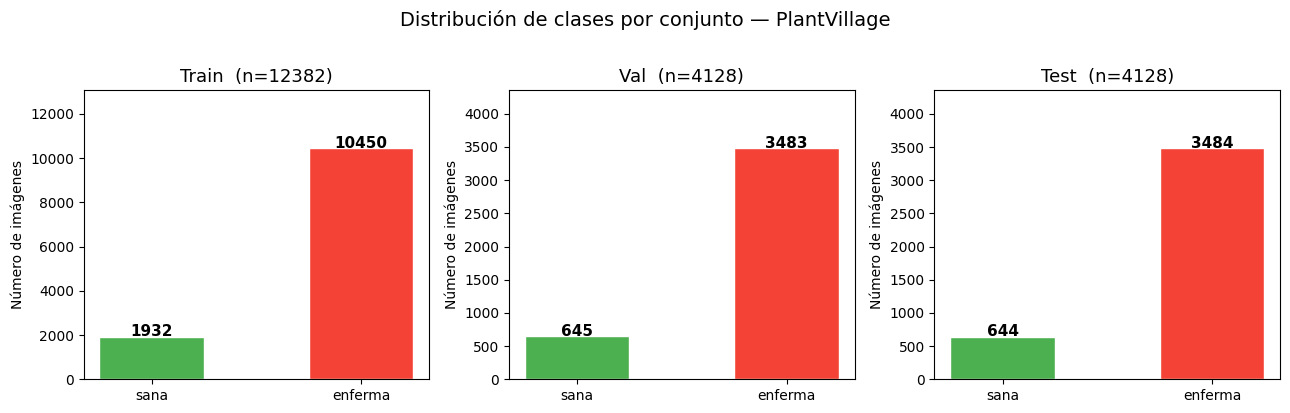

Figura guardada: eda_distribucion.png


In [9]:
# importamos las librerias necesarias para visualizacion y manejo de rutas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

from pathlib import Path
# redefinimos binary_dir en caso de que la sesion se haya reiniciado
BINARY_DIR = Path("/kaggle/working/binary")

#Distribución de clases por split
splits = ["train", "val", "test"]
clases = ["sana", "enferma"]

conteos = {split: {clase: len(list((BINARY_DIR / split / clase).glob("*")))
                   for clase in clases}
           for split in splits}
# creamos una figura con tres subplots, uno por cada conjunto (train, val, test)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# verde para sana, rojo para enferma
colores = ["#4CAF50", "#F44336"]

for ax, split in zip(axes, splits):
    valores = [conteos[split][c] for c in clases]
     # graficamos las barras de cada clase para el split actual
    bars = ax.bar(clases, valores, color=colores, edgecolor="white", width=0.5)
    ax.set_title(f"{split.capitalize()}  (n={sum(valores)})", fontsize=13)
    ax.set_ylabel("Número de imágenes")
    ax.set_ylim(0, max(valores) * 1.25)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Distribución de clases por conjunto — PlantVillage", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_distribucion.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: eda_distribucion.png")


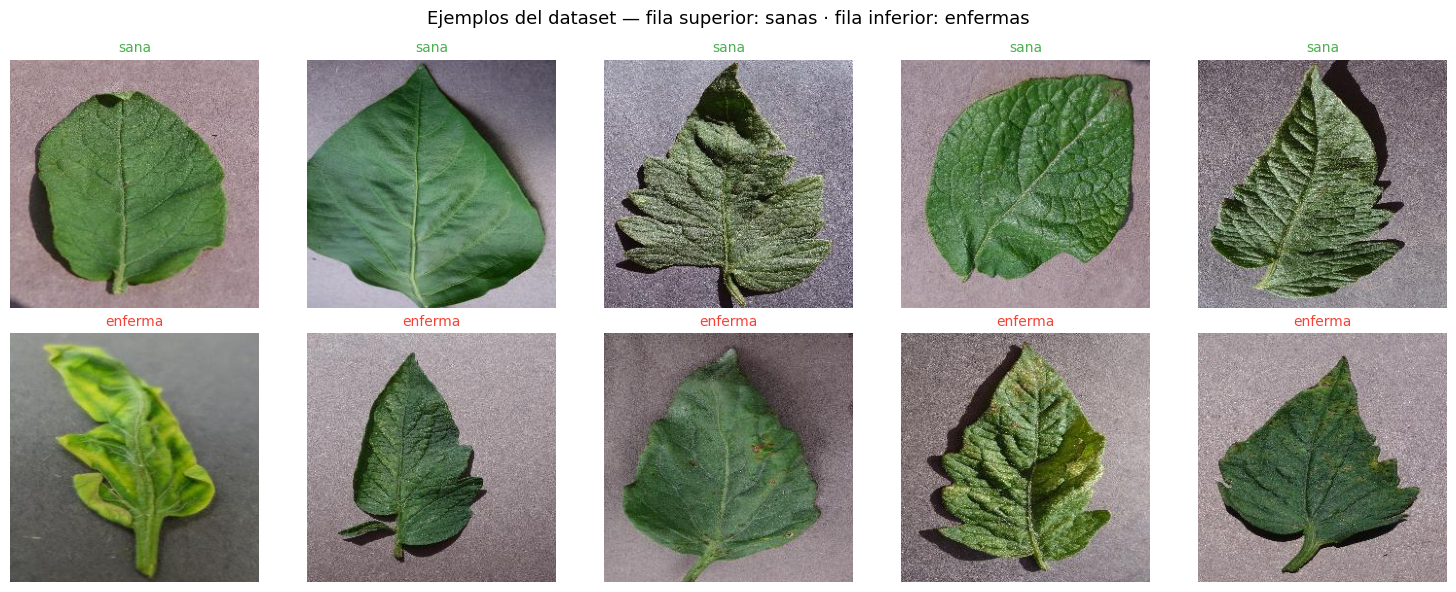

Figura guardada: eda_ejemplos.png


In [10]:
# creamos una cuadricula de 2 filas x 5 columnas para mostrar ejemplos visuales del dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Ejemplos del dataset — fila superior: sanas · fila inferior: enfermas",
             fontsize=13)
# determinamos en que fila va esta imagen segun su clase
for col, clase in enumerate(["sana", "enferma"] * 5):
    fila   = 0 if clase == "sana" else 1
    col_ax = col if col < 5 else col - 5
    ax     = axes[fila][col_ax]

     # obtenemos la lista de imagenes disponibles para esta clase en el conjunto de train
    carpeta   = BINARY_DIR / "train" / clase
    img_paths = list(carpeta.glob("*"))
    img_path  = img_paths[col_ax * 50 % len(img_paths)]
# etiqueta de la clase con color verde para sana y rojo para enferma
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(clase, fontsize=10,
                 color="#4CAF50" if clase == "sana" else "#F44336")

plt.tight_layout()
plt.savefig("eda_ejemplos.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: eda_ejemplos.png")


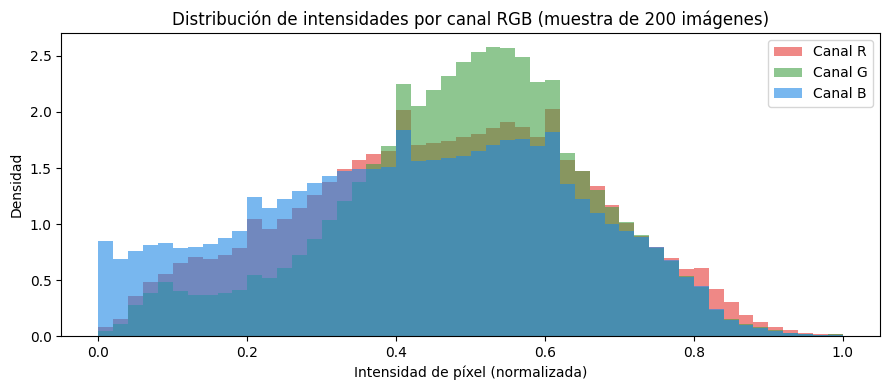

In [11]:
# tomamos una muestra de 200 imagenes para analizar la distribucion de pixeles por canal
# 100 imagenes sanas + 100 enfermas del conjunto de entrenamiento
sample_paths = list((BINARY_DIR / "train" / "sana").glob("*"))[:100] + \
               list((BINARY_DIR / "train" / "enferma").glob("*"))[:100]
 # normalizamos al rango [0, 1] si la imagen esta en rango [0, 255]
r_vals, g_vals, b_vals = [], [], []
for p in sample_paths:
    img = mpimg.imread(str(p))
    if img.max() > 1:
        img = img / 255.0
    if img.ndim == 3 and img.shape[2] >= 3:
        r_vals.extend(img[:, :, 0].flatten().tolist())
        g_vals.extend(img[:, :, 1].flatten().tolist())
        b_vals.extend(img[:, :, 2].flatten().tolist())
# graficamos los histogramas superpuestos de los tres canales
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(r_vals, bins=50, color="#E53935", alpha=0.6, label="Canal R", density=True)
ax.hist(g_vals, bins=50, color="#43A047", alpha=0.6, label="Canal G", density=True)
ax.hist(b_vals, bins=50, color="#1E88E5", alpha=0.6, label="Canal B", density=True)
ax.set_xlabel("Intensidad de píxel (normalizada)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de intensidades por canal RGB (muestra de 200 imágenes)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_pixeles.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Preprocesamiento y DataLoaders


In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# todas las imagenes se redimensionan a 224x224 para ser compatibles con las arquitecturas cnn
# el batch size de 32 es un equilibrio entre velocidad de entrenamiento y uso de memoria gpu
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
# media y desviacion estandar de imagenet
# usamos estos valores porque nuestros modelos con transfer learning (resnet18)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# transformaciones para validacion y prueba
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# creamos los dataloaders que se encargan de entregar los batches durante el entrenamiento
train_dataset = datasets.ImageFolder(BINARY_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(BINARY_DIR / "val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(BINARY_DIR / "test",  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Clases detectadas:", train_dataset.classes)
print(f"  0 → {train_dataset.classes[0]}  |  1 → {train_dataset.classes[1]}")
print(f"\nTamaños:")
print(f"  Train : {len(train_dataset)} imágenes  ({len(train_loader)} batches)")
print(f"  Val   : {len(val_dataset)} imágenes  ({len(val_loader)} batches)")
print(f"  Test  : {len(test_dataset)} imágenes  ({len(test_loader)} batches)")


Clases detectadas: ['enferma', 'sana']
  0 → enferma  |  1 → sana

Tamaños:
  Train : 12382 imágenes  (387 batches)
  Val   : 4128 imágenes  (129 batches)
  Test  : 4128 imágenes  (129 batches)


Shape del batch: torch.Size([32, 3, 224, 224])
Etiquetas: [0, 0, 0, 0, 0, 1, 0, 0]


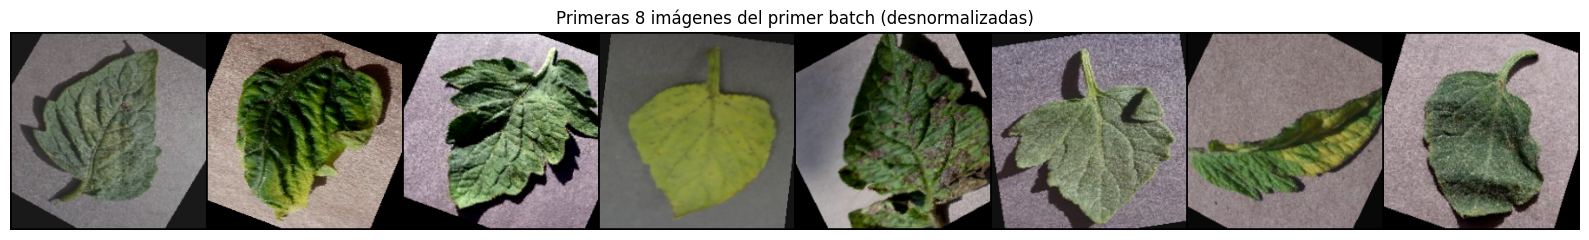

In [13]:
import torchvision
# obtenemos el primer batch del dataloader de entrenamiento para verificar que todo funciona
imagenes, etiquetas = next(iter(train_loader))
# verificamos que el shape del batch sea el esperado: [32, 3, 224, 224]
print(f"Shape del batch: {imagenes.shape}")
print(f"Etiquetas: {etiquetas[:8].tolist()}")

def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

grid = torchvision.utils.make_grid(
    [desnormalizar(imagenes[i]) for i in range(8)], nrow=8
)
# permute(1, 2, 0) convierte el tensor de formato (c, h, w) a (h, w, c) que espera matplotlib
plt.figure(figsize=(16, 3))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Primeras 8 imágenes del primer batch (desnormalizadas)")
plt.axis("off")
plt.tight_layout()
plt.show()


## 5. Funciones de Entrenamiento y Evaluación


In [14]:
import torch
from sklearn.metrics import f1_score, recall_score, accuracy_score, roc_auc_score
from tqdm.notebook import tqdm

# configuramos el dispositivo: si hay gpu disponible se usa cuda, si no cpu
# esta variable se usa en todas las funciones para mover tensores al dispositivo correcto
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"entrenando en: {DEVICE}")


def entrenar_una_epoca(modelo, loader, criterio, optimizador): 
    # ejecuta una epoca completa de entrenamiento.
    # modo entrenamiento: activa dropout y batch normalization en modo train
    modelo.train()
    perdida_total = 0.0

    for imagenes, etiquetas in loader:
        # movemos los datos al dispositivo configurado (gpu o cpu)
        imagenes  = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)

        # limpiamos los gradientes acumulados del paso anterior
        optimizador.zero_grad()

        # forward pass: calculamos las predicciones del modelo
        salidas = modelo(imagenes)

        # calculamos la perdida comparando predicciones con etiquetas reales
        perdida = criterio(salidas, etiquetas)

        # backward pass: calculamos los gradientes de cada parametro
        perdida.backward()

        # actualizamos los pesos usando los gradientes calculados
        optimizador.step()

        # acumulamos la perdida ponderada por el numero de imagenes en el batch
        perdida_total += perdida.item() * imagenes.size(0)

    # retornamos la perdida promedio por imagen
    return perdida_total / len(loader.dataset)


def evaluar(modelo, loader):
    # evalua el modelo sobre un conjunto de datos sin actualizar los pesos.
    # modo evaluacion: desactiva dropout y usa estadisticas acumuladas en batch norm
    modelo.eval()
    perdida_total = 0.0
    criterio = torch.nn.CrossEntropyLoss()

    # listas para acumular predicciones, etiquetas reales y probabilidades
    todas_preds, todas_labels, todas_probs = [], [], []

    # torch.no_grad() evita calcular gradientes, lo que ahorra memoria y acelera la inferencia
    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes  = imagenes.to(DEVICE)
            etiquetas = etiquetas.to(DEVICE)

            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_total += perdida.item() * imagenes.size(0)

            # softmax convierte los logits en probabilidades que suman 1
            # tomamos la probabilidad de la clase 1 (sana) para calcular auc-roc
            probs = torch.softmax(salidas, dim=1)[:, 1]

            # argmax selecciona la clase con mayor logit como prediccion final
            preds = salidas.argmax(dim=1)

            # movemos a cpu y convertimos a numpy para compatibilidad con sklearn
            todas_preds.extend(preds.cpu().numpy())
            todas_labels.extend(etiquetas.cpu().numpy())
            todas_probs.extend(probs.cpu().numpy())

    perdida_prom = perdida_total / len(loader.dataset)

    # calculamos las metricas de evaluacion con sklearn
    acc    = accuracy_score(todas_labels, todas_preds)
    f1     = f1_score(todas_labels, todas_preds, average="macro")  # macro: promedio no ponderado por clase
    recall = recall_score(todas_labels, todas_preds, pos_label=1)  # recall solo de la clase sana (1)
    auc    = roc_auc_score(todas_labels, todas_probs)

    return perdida_prom, acc, f1, recall, auc


def ciclo_entrenamiento(modelo, train_loader, val_loader, optimizador,
                         scheduler, n_epocas=30, paciencia=10,
                         nombre_modelo="modelo"):
    #ciclo completo de entrenamiento con early stopping y guardado del mejor modelo.
    criterio = torch.nn.CrossEntropyLoss()
    modelo   = modelo.to(DEVICE)

    # diccionario para registrar el historial de metricas por epoca
    historial = {
        "train_loss": [], "val_loss": [],
        "val_acc": [], "val_f1": [], "val_recall": [], "val_auc": []
    }

    mejor_f1          = 0.0   # mejor f1 de validacion visto hasta ahora
    epocas_sin_mejora = 0     # contador de epocas consecutivas sin mejora
    mejor_estado      = None  # copia de los pesos del mejor modelo

    for epoca in range(1, n_epocas + 1):

        # entrenamos una epoca y evaluamos en validacion
        train_loss = entrenar_una_epoca(modelo, train_loader, criterio, optimizador)
        val_loss, val_acc, val_f1, val_recall, val_auc = evaluar(modelo, val_loader)

        # el scheduler reduce el learning rate si val_loss no mejora en 'patience' epocas
        scheduler.step(val_loss)

        # guardamos las metricas de esta epoca en el historial
        historial["train_loss"].append(train_loss)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)
        historial["val_f1"].append(val_f1)
        historial["val_recall"].append(val_recall)
        historial["val_auc"].append(val_auc)

        print(f"epoca {epoca:3d}/{n_epocas}  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"f1={val_f1:.4f}  recall={val_recall:.4f}  auc={val_auc:.4f}")

        # criterio de seleccion del mejor modelo: mayor f1 de validacion
        if val_f1 > mejor_f1:
            mejor_f1          = val_f1
            epocas_sin_mejora = 0

            # guardamos una copia de los pesos en cpu para no ocupar memoria gpu
            mejor_estado = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}

            # guardamos el checkpoint en disco para poder recuperarlo si la sesion se corta
            torch.save(mejor_estado, f"{nombre_modelo}_best.pt")
        else:
            epocas_sin_mejora += 1

            # si no hay mejora, detenemos el entrenamiento
            if epocas_sin_mejora >= paciencia:
                print(f"\nearly stopping en epoca {epoca}. mejor f1: {mejor_f1:.4f}")
                break

    # al terminar, cargamos los pesos de la mejor epoca antes de retornar el modelo
    if mejor_estado is not None:
        modelo.load_state_dict({k: v.to(DEVICE) for k, v in mejor_estado.items()})

    return modelo, historial


def graficar_historial(historial, titulo=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epocas = range(1, len(historial["train_loss"]) + 1)

    # curva de perdida: comparamos train loss vs val loss
    # un gap grande entre ambas indica overfitting
    axes[0].plot(epocas, historial["train_loss"], label="train loss", color="#1E88E5")
    axes[0].plot(epocas, historial["val_loss"],   label="val loss",   color="#F44336")
    axes[0].set_xlabel("epoca")
    axes[0].set_ylabel("crossentropyloss")
    axes[0].set_title("perdida durante el entrenamiento")
    axes[0].legend()

    # curva de metricas: f1 y recall sobre el conjunto de validacion
    axes[1].plot(epocas, historial["val_f1"],     label="val f1",     color="#43A047")
    axes[1].plot(epocas, historial["val_recall"], label="val recall",  color="#FB8C00")
    axes[1].set_xlabel("epoca")
    axes[1].set_ylabel("metrica")
    axes[1].set_title("f1 y recall en validacion")
    axes[1].legend()

    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{titulo.replace(' ', '_')}_curvas.png", dpi=120, bbox_inches="tight")
    plt.show()

Entrenando en: cuda


## 6. Modelo 1 — CNN Baseline (from scratch)


In [15]:
import torch.nn as nn
 # bloque de extraccion de caracteristicas
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNBaseline, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        # clasificador: toma el vector de 256 caracteristicas y produce 2 logits
        # dropout(0.5) desactiva el 50% de las neuronas aleatoriamente durante el entrenamiento
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
         # extraccion de caracteristicas
        x = self.features(x)
        x = self.gap(x)
        # clasificacion final
        x = self.classifier(x)
        return x
# verificamos que el modelo funciona con un batch de prueba antes de entrenar
modelo1 = CNNBaseline(num_classes=2)
dummy   = torch.zeros(4, 3, 224, 224)
# la salida debe tener shape [4, 2]: 4 imagenes, 2 logits cada una
print(f"Shape de salida: {modelo1(dummy).shape}")
print(f"Parámetros entrenables: {sum(p.numel() for p in modelo1.parameters() if p.requires_grad):,}")


Shape de salida: torch.Size([4, 2])
Parámetros entrenables: 455,682


In [16]:
import torch.optim as optim
# instanciamos el modelo 1 desde cero con pesos inicializados aleatoriamente
# optimizador adam: ajusta el learning rate de cada parametro de forma adaptativa
# lr=1e-3 es un valor estandar para entrenar cnns desde cero
modelo1      = CNNBaseline(num_classes=2)
optimizador1 = optim.Adam(modelo1.parameters(), lr=1e-3)
scheduler1   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador1, mode="min", patience=5, factor=0.5
)

print("=" * 60)
print("Entrenando Modelo 1 — CNN Baseline")
print("=" * 60)
# lanzamos el ciclo de entrenamiento completo
# n_epocas=30 es el maximo de epocas permitidas
# paciencia=10: el early stopping detiene el entrenamiento si el val_f1
modelo1, hist1 = ciclo_entrenamiento(
    modelo1, train_loader, val_loader,
    optimizador1, scheduler1,
    n_epocas=30, paciencia=10,
    nombre_modelo="modelo1_baseline"
)


Entrenando Modelo 1 — CNN Baseline
Época   1/30  train_loss=0.2425  val_loss=0.2028  F1=0.8541  Recall=0.9085  AUC=0.9670
Época   2/30  train_loss=0.1575  val_loss=0.1693  F1=0.8738  Recall=0.8713  AUC=0.9744
Época   3/30  train_loss=0.1077  val_loss=0.5245  F1=0.7584  Recall=0.9473  AUC=0.9560
Época   4/30  train_loss=0.0909  val_loss=0.1502  F1=0.9003  Recall=0.9473  AUC=0.9864
Época   5/30  train_loss=0.0783  val_loss=0.0844  F1=0.9369  Recall=0.8574  AUC=0.9923
Época   6/30  train_loss=0.0779  val_loss=0.0934  F1=0.9394  Recall=0.9411  AUC=0.9919
Época   7/30  train_loss=0.0706  val_loss=0.0876  F1=0.9326  Recall=0.8806  AUC=0.9910
Época   8/30  train_loss=0.0651  val_loss=0.0981  F1=0.9341  Recall=0.9566  AUC=0.9935
Época   9/30  train_loss=0.0577  val_loss=0.1429  F1=0.9142  Recall=0.9457  AUC=0.9881
Época  10/30  train_loss=0.0648  val_loss=0.0870  F1=0.9449  Recall=0.9659  AUC=0.9948
Época  11/30  train_loss=0.0554  val_loss=0.0616  F1=0.9591  Recall=0.9581  AUC=0.9956
Época  1

### análisis de overfitting — modelo 1 

el modelo entrenó durante 24 épocas antes de que el early stopping lo detuviera,
con un mejor f1 de validación de 0.9801.


la train_loss cayó de forma sostenida desde 0.2425 (época 1) hasta 0.0218 (época 24),
mientras que la val_loss tuvo un comportamiento irregular, con picos  en las
épocas 3  y 9 antes de estabilizarse.
este comportamiento  es una señal temprana de overfitting

a pesar del overfitting moderado, el modelo alcanzó métricas sólidas:
f1=0.9784, recall=0.9628 y auc=0.9988 en su mejor época (24).
el recall alto indica que el modelo detecta bien las plantas enfermas.

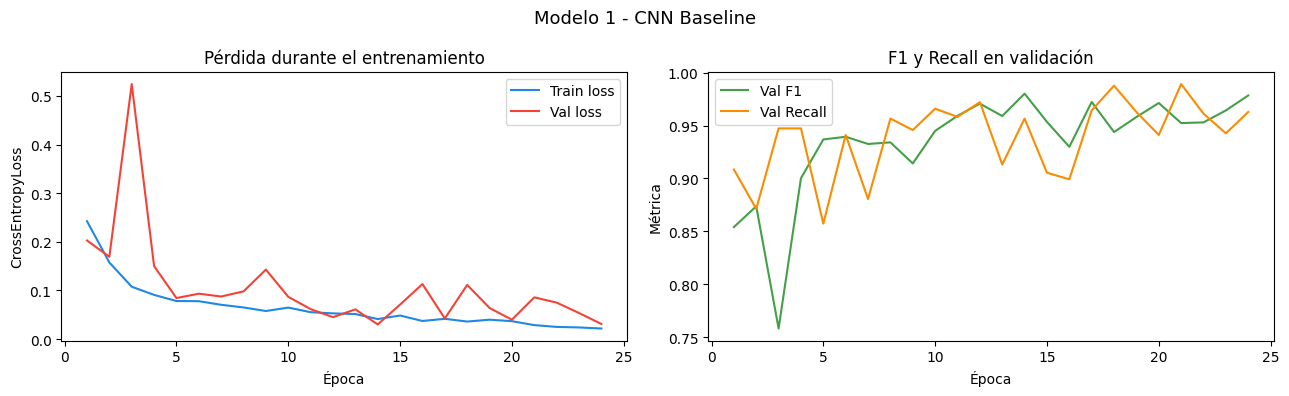


 Resultados Modelo 1 en TEST:
   Accuracy : 0.9886
   F1-score : 0.9781
   Recall   : 0.9503
   AUC-ROC  : 0.9990


In [17]:
graficar_historial(hist1, titulo="Modelo 1 - CNN Baseline")
_, acc1, f1_1, rec1, auc1 = evaluar(modelo1, test_loader)
print(f"\n Resultados Modelo 1 en TEST:")
print(f"   Accuracy : {acc1:.4f}")
print(f"   F1-score : {f1_1:.4f}")
print(f"   Recall   : {rec1:.4f}")
print(f"   AUC-ROC  : {auc1:.4f}")


## 7. Modelo 2 — CNN con más Regularización


In [18]:
# modelo 2: misma arquitectura convolucional que el modelo 1 pero con mayor regularizacion en el clasificador.
class CNNRegularizada(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNRegularizada, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x
# instanciamos el modelo 2
# weight_decay=1e-4 agrega regularizacion l2 directamente en el optimizador
modelo2      = CNNRegularizada(num_classes=2)
optimizador2 = optim.Adam(modelo2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler2   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador2, mode="min", patience=5, factor=0.5
)

print("=" * 60)
print("Entrenando Modelo 2 — CNN Regularizada")
print("=" * 60)
# entrenamos con los mismos hiperparametros que el modelo 1
modelo2, hist2 = ciclo_entrenamiento(
    modelo2, train_loader, val_loader,
    optimizador2, scheduler2,
    n_epocas=30, paciencia=10,
    nombre_modelo="modelo2_regularizado"
)


Entrenando Modelo 2 — CNN Regularizada
Época   1/30  train_loss=0.2504  val_loss=0.2558  F1=0.8253  Recall=0.8915  AUC=0.9591
Época   2/30  train_loss=0.1672  val_loss=0.1302  F1=0.8993  Recall=0.7767  AUC=0.9796
Época   3/30  train_loss=0.1188  val_loss=0.1413  F1=0.8949  Recall=0.7426  AUC=0.9820
Época   4/30  train_loss=0.0983  val_loss=0.2507  F1=0.8623  Recall=0.9566  AUC=0.9819
Época   5/30  train_loss=0.0900  val_loss=0.0900  F1=0.9338  Recall=0.8713  AUC=0.9907
Época   6/30  train_loss=0.0788  val_loss=0.1022  F1=0.9261  Recall=0.9395  AUC=0.9908
Época   7/30  train_loss=0.0713  val_loss=0.0902  F1=0.9363  Recall=0.9287  AUC=0.9914
Época   8/30  train_loss=0.0736  val_loss=0.0611  F1=0.9547  Recall=0.9411  AUC=0.9958
Época   9/30  train_loss=0.0663  val_loss=0.1158  F1=0.9258  Recall=0.9271  AUC=0.9892
Época  10/30  train_loss=0.0610  val_loss=0.0771  F1=0.9470  Recall=0.8977  AUC=0.9938
Época  11/30  train_loss=0.0637  val_loss=0.0597  F1=0.9574  Recall=0.9054  AUC=0.9956
Époc

### análisis de overfitting — modelo 2

el modelo entrenó las 30 épocas completas sin que se activara el early stopping,
lo que indica que el f1 de validación seguía mejorando o manteniéndose estable
hasta el final del entrenamiento.

**comportamiento de la pérdida:**
la train_loss bajó de 0.2504 (época 1) a 0.0352 (época 30), una caída sostenida
similar al modelo 1. sin embargo, la val_loss se mantuvo mucho más estable durante
todo el entrenamiento, esto indica que la regularización adicional
dropout doble y weight decay cumplió su objetivo de estabilizar el aprendizaje.

**métricas de validación:**
el modelo alcanzó su mejor f1 en torno a la época 25 con f1=0.9802,
recall=0.9643 y auc=0.9988. los valores son muy similares al modelo 1,
lo que sugiere que la regularización adicional no perjudicó el desempeño
pero sí mejoró la estabilidad del entrenamiento.


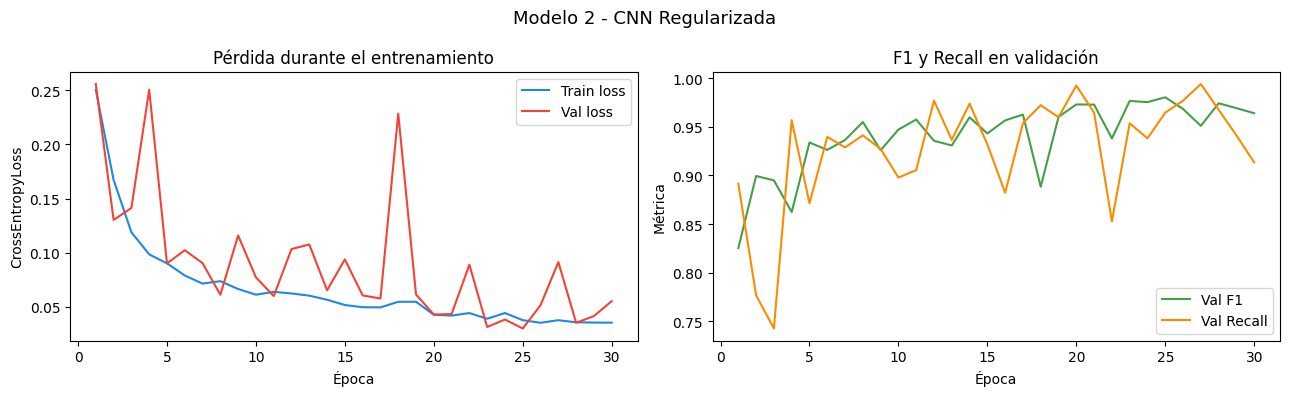


 Resultados Modelo 2 en TEST:
   Accuracy : 0.9893
   F1-score : 0.9798
   Recall   : 0.9689
   AUC-ROC  : 0.9990


In [19]:
graficar_historial(hist2, titulo="Modelo 2 - CNN Regularizada")
_, acc2, f1_2, rec2, auc2 = evaluar(modelo2, test_loader)
print(f"\n Resultados Modelo 2 en TEST:")
print(f"   Accuracy : {acc2:.4f}")
print(f"   F1-score : {f1_2:.4f}")
print(f"   Recall   : {rec2:.4f}")
print(f"   AUC-ROC  : {auc2:.4f}")


## 8. Modelo 3 — Transfer Learning con ResNet18


In [20]:
from torchvision import models
# cargamos resnet18 con pesos preentrenados en imagenet
# los filtros aprendidos detectan bordes, texturas y formas utiles para cualquier tarea visual
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet.parameters():
    param.requires_grad = False
# n_features = 512, que es el numero de salidas del bloque residual final de resnet18
n_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(n_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(256, 2),
)
modelo3 = resnet
# contamos cuantos parametros son entrenables en esta fase
n_entrenable = sum(p.numel() for p in modelo3.parameters() if p.requires_grad)
n_total      = sum(p.numel() for p in modelo3.parameters())
print(f"Parámetros entrenables (Fase 1): {n_entrenable:,} / {n_total:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]

Parámetros entrenables (Fase 1): 131,842 / 11,308,354


In [21]:
#entrenamos unicamente la nueva cabeza clasificadora
optimizador3_fase1 = optim.Adam(
    filter(lambda p: p.requires_grad, modelo3.parameters()),
    lr=1e-4, weight_decay=1e-4
)
# mismo scheduler
scheduler3_fase1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador3_fase1, mode="min", patience=5, factor=0.5
)

print("=" * 60)
print("Modelo 3 — Fase 1: solo clasificador (backbone congelado)")
print("=" * 60)
# entrenamos por un maximo de 10 epocas con paciencia de 7
modelo3, hist3_fase1 = ciclo_entrenamiento(
    modelo3, train_loader, val_loader,
    optimizador3_fase1, scheduler3_fase1,
    n_epocas=10, paciencia=7,
    nombre_modelo="modelo3_fase1"
)


Modelo 3 — Fase 1: solo clasificador (backbone congelado)
Época   1/10  train_loss=0.2643  val_loss=0.1309  F1=0.9032  Recall=0.7783  AUC=0.9839
Época   2/10  train_loss=0.1441  val_loss=0.1077  F1=0.9281  Recall=0.9318  AUC=0.9908
Época   3/10  train_loss=0.1213  val_loss=0.0915  F1=0.9392  Recall=0.9364  AUC=0.9927
Época   4/10  train_loss=0.1051  val_loss=0.0905  F1=0.9375  Recall=0.9612  AUC=0.9944
Época   5/10  train_loss=0.0899  val_loss=0.0960  F1=0.9330  Recall=0.9736  AUC=0.9949
Época   6/10  train_loss=0.0936  val_loss=0.0738  F1=0.9554  Recall=0.9597  AUC=0.9954
Época   7/10  train_loss=0.0836  val_loss=0.0649  F1=0.9571  Recall=0.9597  AUC=0.9965
Época   8/10  train_loss=0.0814  val_loss=0.0722  F1=0.9534  Recall=0.9736  AUC=0.9965
Época   9/10  train_loss=0.0773  val_loss=0.0725  F1=0.9510  Recall=0.9767  AUC=0.9968
Época  10/10  train_loss=0.0738  val_loss=0.1026  F1=0.9301  Recall=0.9860  AUC=0.9968


### análisis de overfitting — modelo 3 

el entrenamiento se dividió en dos fases con un total de 20 épocas.
en la fase 2 se descongeló layer4, pasando de x parámetros entrenables
a 8,525,570, lo que permitió al modelo adaptar las representaciones de
alto nivel de imagenet al dominio de hojas de plantas.

**(épocas 1–10):**
la train_loss bajó de 0.0602 a 0.0129 y la val_loss de 0.0439 a 0.0197,
ambas cayendo de forma suave
este comportamiento es el mejor de los tres modelos: las dos curvas
descienden juntas, lo que indica que el modelo generaliza bien y no está
memorizando los datos de entrenamiento.

**métricas de validación:**
el modelo alcanzó f1=0.9887, recall=0.9969 y auc=0.9997 en la época 9,
los valores más altos de los tres modelos. el recall de 0.9969 quiere decir que  el modelo prácticamente no deja plantas
enfermas sin detectar, que es el objetivo central del proyecto.

**comparación final con modelos 1 y 2:**
- curvas más suaves y estables (sin los picos del modelo 1)
- mejor f1, recall y auc en validación
- convergió en menos épocas totales (20 vs 24–30)
- el transfer learning demostró ser la estrategia más efectiva

In [22]:
#descongelamos layer4 del backbone de resnet18
for param in modelo3.layer4.parameters():
    param.requires_grad = True

print(f"Parámetros entrenables (Fase 2): {sum(p.numel() for p in modelo3.parameters() if p.requires_grad):,}")
# creamos un nuevo optimizador que incluye los parametros de layer4
optimizador3_fase2 = optim.Adam(
    filter(lambda p: p.requires_grad, modelo3.parameters()),
    lr=1e-5, weight_decay=1e-4
)
scheduler3_fase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador3_fase2, mode="min", patience=5, factor=0.5
)

print("=" * 60)
print("Modelo 3 — Fase 2: fine-tuning de layer4")
print("=" * 60)
# continuamos el entrenamiento desde donde quedo la fase 1
modelo3, hist3_fase2 = ciclo_entrenamiento(
    modelo3, train_loader, val_loader,
    optimizador3_fase2, scheduler3_fase2,
    n_epocas=10, paciencia=7,
    nombre_modelo="modelo3_fase2"
)


Parámetros entrenables (Fase 2): 8,525,570
Modelo 3 — Fase 2: fine-tuning de layer4
Época   1/10  train_loss=0.0602  val_loss=0.0439  F1=0.9693  Recall=0.9876  AUC=0.9990
Época   2/10  train_loss=0.0432  val_loss=0.0386  F1=0.9737  Recall=0.9907  AUC=0.9993
Época   3/10  train_loss=0.0284  val_loss=0.0336  F1=0.9794  Recall=0.9938  AUC=0.9995
Época   4/10  train_loss=0.0254  val_loss=0.0234  F1=0.9851  Recall=0.9938  AUC=0.9995
Época   5/10  train_loss=0.0213  val_loss=0.0281  F1=0.9803  Recall=0.9953  AUC=0.9996
Época   6/10  train_loss=0.0219  val_loss=0.0207  F1=0.9878  Recall=0.9953  AUC=0.9996
Época   7/10  train_loss=0.0166  val_loss=0.0222  F1=0.9856  Recall=0.9969  AUC=0.9997
Época   8/10  train_loss=0.0168  val_loss=0.0190  F1=0.9873  Recall=0.9953  AUC=0.9997
Época   9/10  train_loss=0.0142  val_loss=0.0199  F1=0.9887  Recall=0.9969  AUC=0.9996
Época  10/10  train_loss=0.0129  val_loss=0.0197  F1=0.9869  Recall=0.9969  AUC=0.9997


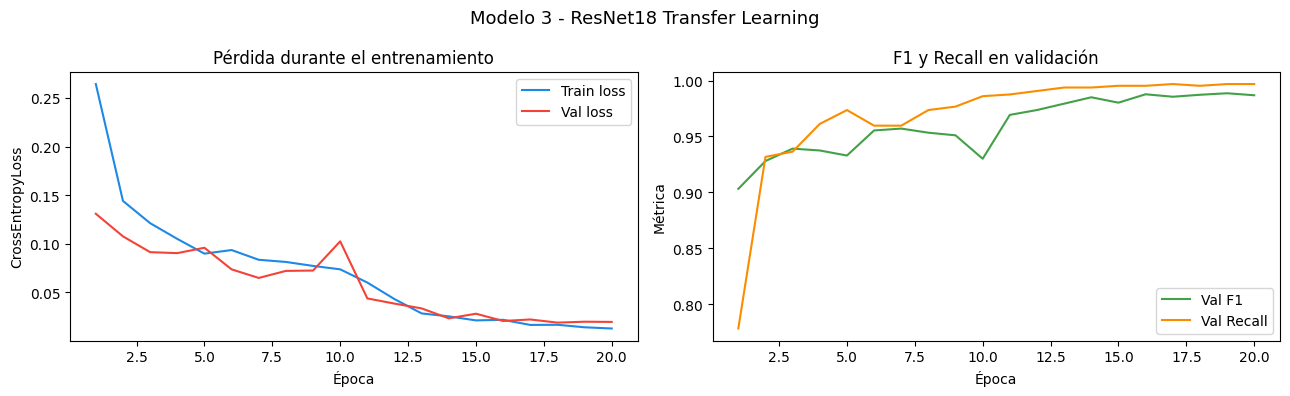


 Resultados Modelo 3 en TEST:
   Accuracy : 0.9939
   F1-score : 0.9887
   Recall   : 0.9984
   AUC-ROC  : 0.9998


In [23]:
hist3_completo = {k: hist3_fase1[k] + hist3_fase2[k] for k in hist3_fase1}
graficar_historial(hist3_completo, titulo="Modelo 3 - ResNet18 Transfer Learning")

_, acc3, f1_3, rec3, auc3 = evaluar(modelo3, test_loader)
print(f"\n Resultados Modelo 3 en TEST:")
print(f"   Accuracy : {acc3:.4f}")
print(f"   F1-score : {f1_3:.4f}")
print(f"   Recall   : {rec3:.4f}")
print(f"   AUC-ROC  : {auc3:.4f}")


## 9. Comparación Final de los Tres Modelos


In [25]:
import pandas as pd
# tabla 1: comparacion de los tres modelos solo en el conjunto de prueba (test)
resultados = pd.DataFrame({
    "Modelo": [
        "Modelo 1 — CNN Baseline",
        "Modelo 2 — CNN Regularizada",
        "Modelo 3 — ResNet18 TL"
    ],
    "Accuracy": [acc1, acc2, acc3],
    "F1-score": [f1_1, f1_2, f1_3],
    "Recall (enferma)": [rec1, rec2, rec3],
    "AUC-ROC": [auc1, auc2, auc3],
})

resultados_fmt = resultados.style.highlight_max(
    subset=["Accuracy", "F1-score", "Recall (enferma)", "AUC-ROC"],
    color="lightgreen"
).format({
    "Accuracy": "{:.4f}", "F1-score": "{:.4f}",
    "Recall (enferma)": "{:.4f}", "AUC-ROC": "{:.4f}"
})
display(resultados_fmt)

# tabla 2: comparacion de train vs validacion vs test para cada modelo
modelos_eval = [
    ("Modelo 1 — CNN Baseline",     modelo1),
    ("Modelo 2 — CNN Regularizada", modelo2),
    ("Modelo 3 — ResNet18 TL",      modelo3),
]

filas = []
for nombre, modelo in modelos_eval:
    _, tr_acc, tr_f1, tr_rec, tr_auc = evaluar(modelo, train_loader)
    _, va_acc, va_f1, va_rec, va_auc = evaluar(modelo, val_loader)
    _, te_acc, te_f1, te_rec, te_auc = evaluar(modelo, test_loader)

    filas.append({"Modelo": nombre, "Conjunto": "Train",      "Accuracy": tr_acc, "F1": tr_f1, "Recall": tr_rec, "AUC-ROC": tr_auc})
    filas.append({"Modelo": nombre, "Conjunto": "Validación", "Accuracy": va_acc, "F1": va_f1, "Recall": va_rec, "AUC-ROC": va_auc})
    filas.append({"Modelo": nombre, "Conjunto": "Test",       "Accuracy": te_acc, "F1": te_f1, "Recall": te_rec, "AUC-ROC": te_auc})

df_comparacion = pd.DataFrame(filas)
# resalta las filas de test en verde para facilitar la lectura
def resaltar_test(row):
    return ["background-color: #d4edda" if row["Conjunto"] == "Test" else "" for _ in row]

df_fmt = df_comparacion.style.format({
    "Accuracy": "{:.4f}", "F1": "{:.4f}",
    "Recall": "{:.4f}", "AUC-ROC": "{:.4f}"
}).apply(resaltar_test, axis=1)

display(df_fmt)

,Modelo,Accuracy,F1-score,Recall (enferma),AUC-ROC
0,Modelo 1 — CNN Baseline,0.9886,0.9781,0.9503,0.9990
1,Modelo 2 — CNN Regularizada,0.9893,0.9798,0.9689,0.9990
2,Modelo 3 — ResNet18 TL,0.9939,0.9887,0.9984,0.9998


,Modelo,Conjunto,Accuracy,F1,Recall,AUC-ROC
0,Modelo 1 — CNN Baseline,Train,0.9894,0.9797,0.9550,0.9986
1,Modelo 1 — CNN Baseline,Validación,0.9896,0.9801,0.9566,0.9989
2,Modelo 1 — CNN Baseline,Test,0.9886,0.9781,0.9503,0.9990
3,Modelo 2 — CNN Regularizada,Train,0.9935,0.9876,0.9803,0.9992
4,Modelo 2 — CNN Regularizada,Validación,0.9896,0.9802,0.9643,0.9988
5,Modelo 2 — CNN Regularizada,Test,0.9893,0.9798,0.9689,0.9990
6,Modelo 3 — ResNet18 TL,Train,0.9982,0.9966,0.9979,1.0000
7,Modelo 3 — ResNet18 TL,Validación,0.9939,0.9887,0.9969,0.9996
8,Modelo 3 — ResNet18 TL,Test,0.9939,0.9887,0.9984,0.9998


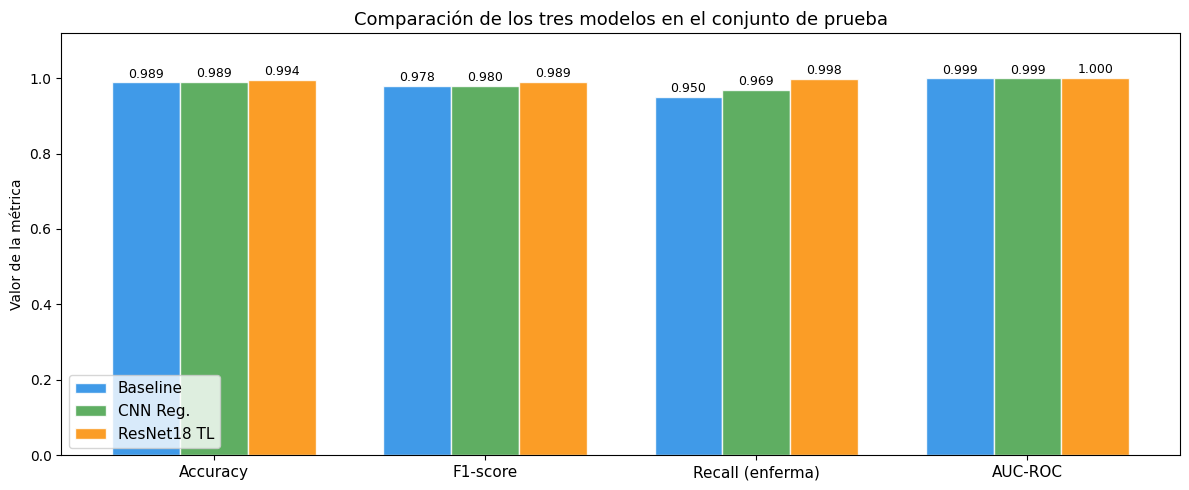

In [26]:
# definimos las metricas y modelos que queremos comparar visualmente
metricas = ["Accuracy", "F1-score", "Recall (enferma)", "AUC-ROC"]
modelos  = ["Baseline", "CNN Reg.", "ResNet18 TL"]
colores  = ["#1E88E5", "#43A047", "#FB8C00"]

x     = np.arange(len(metricas))
ancho = 0.25
# iteramos sobre los tres modelos y dibujamos sus barras desplazadas horizontalmente
fig, ax = plt.subplots(figsize=(12, 5))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    valores = resultados.iloc[i][metricas].values.astype(float)
    bars = ax.bar(x + i * ancho, valores, ancho, label=modelo,
                  color=color, alpha=0.85, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de los tres modelos en el conjunto de prueba", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=120, bbox_inches="tight")
plt.show()


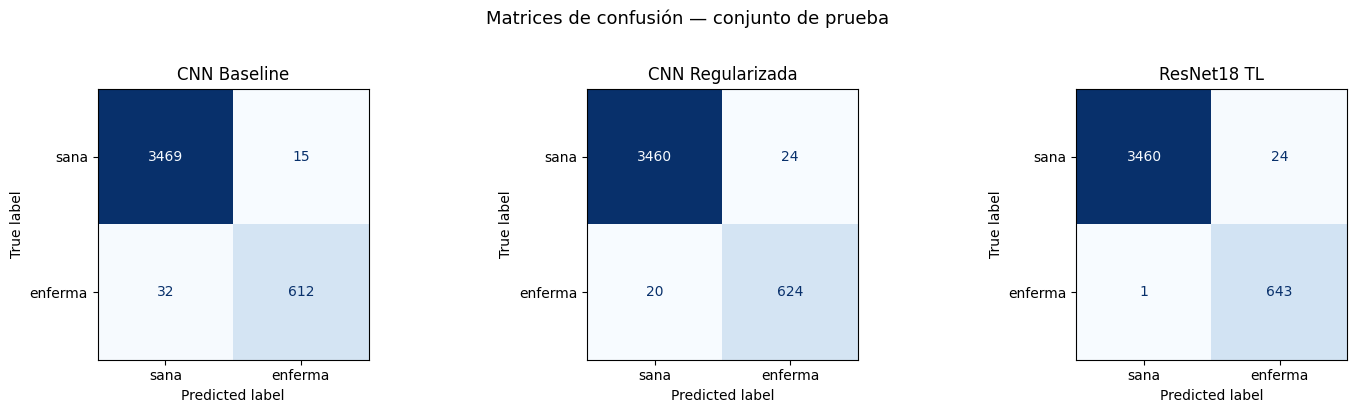

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# creamos una figura con tres subplots, uno por cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nombres_modelos = ["CNN Baseline", "CNN Regularizada", "ResNet18 TL"]

for ax, modelo, nombre in zip(axes, [modelo1, modelo2, modelo3], nombres_modelos):
    modelo.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, ys in test_loader:
            salidas = modelo(imgs.to(DEVICE))
            preds.extend(salidas.argmax(dim=1).cpu().numpy())
            labels.extend(ys.numpy())
    # calculamos la matriz de confusion
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["sana", "enferma"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre, fontsize=12)

plt.suptitle("Matrices de confusión — conjunto de prueba", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Análisis de Errores

Visualizamos ejemplos concretos donde cada modelo falla: falsos negativos 
(planta enferma clasificada como sana) y falsos positivos (planta sana 
clasificada como enferma).

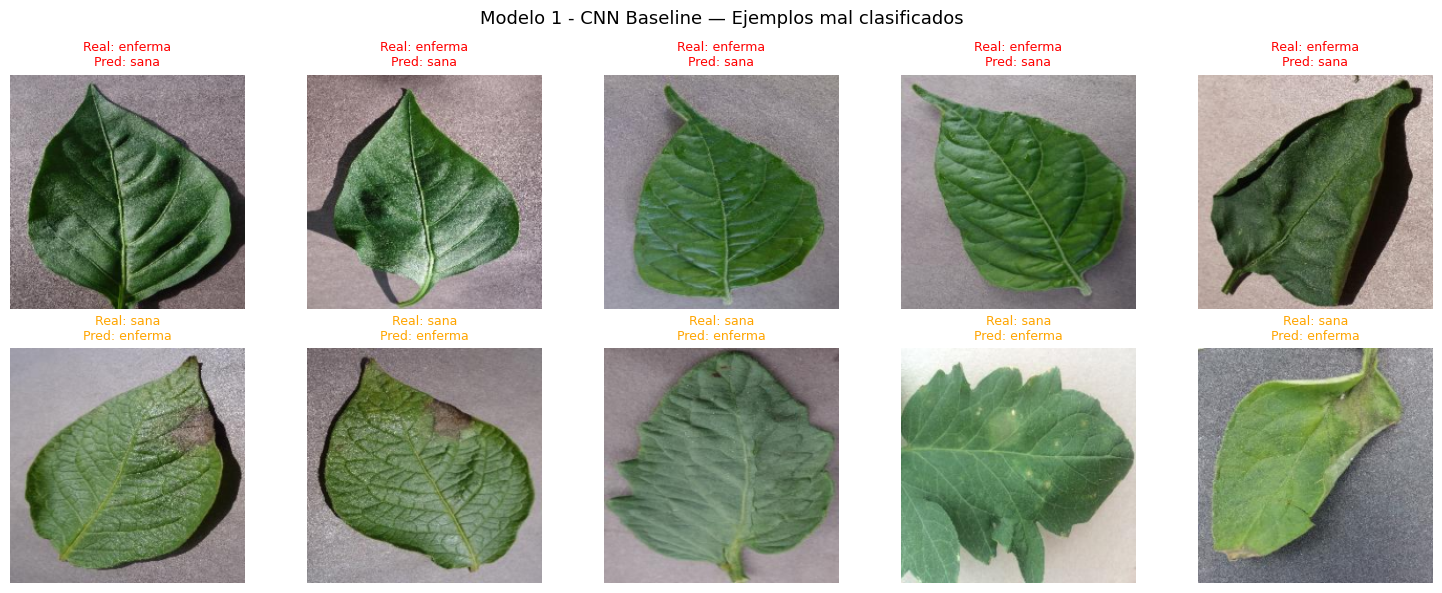

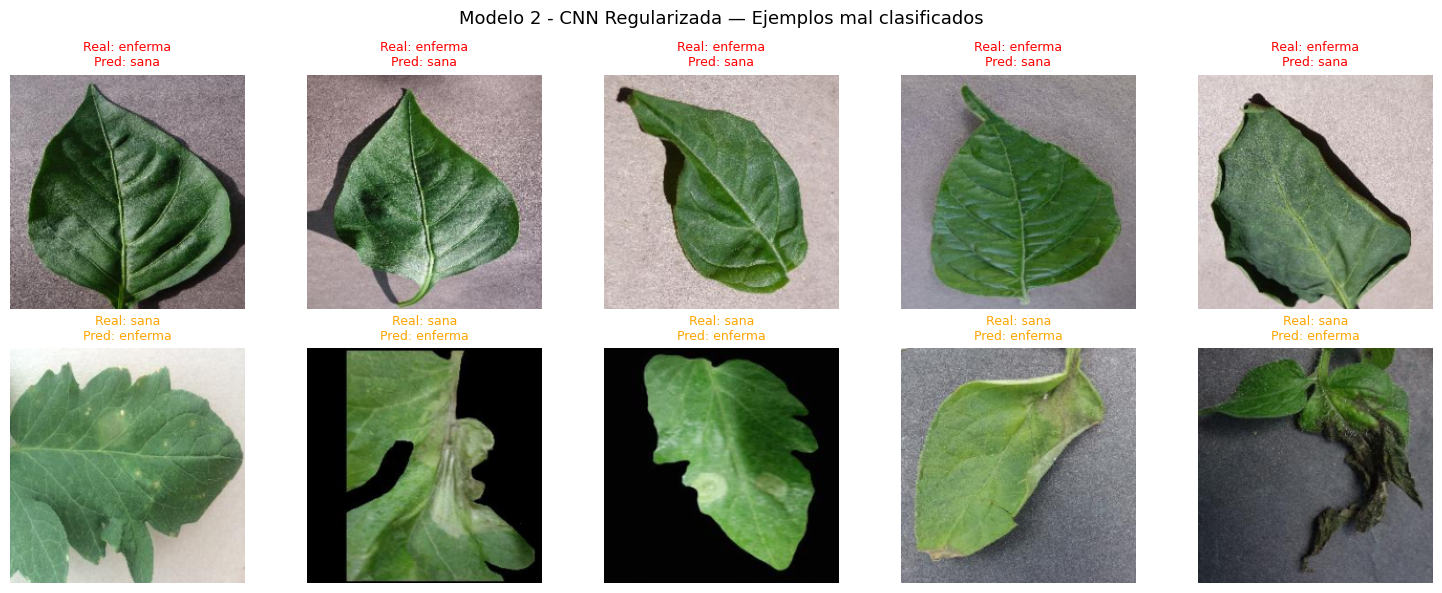

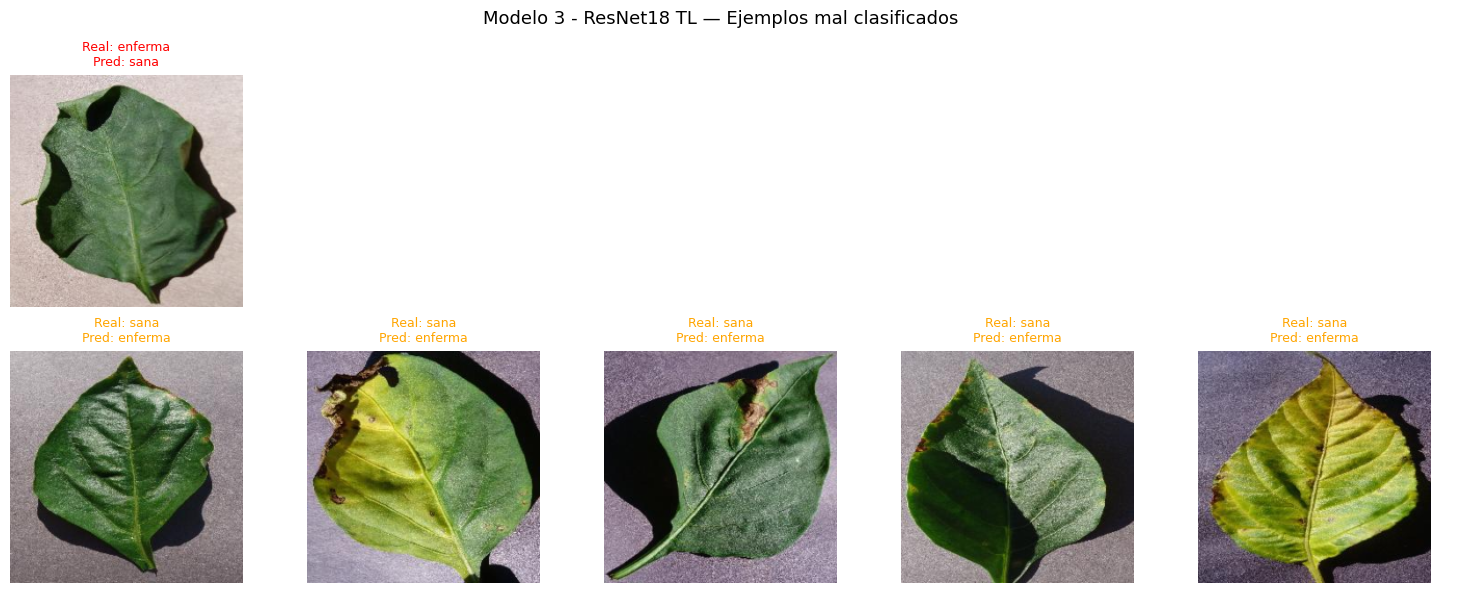

In [28]:
# Análisis de errores imágenes mal clasificadas

def mostrar_errores(modelo, loader, nombre_modelo, n=5):
    modelo.eval()
    falsos_negativos = []  # enferma clasificada como sana
    falsos_positivos = []  # sana clasificada como enferma

    with torch.no_grad():
        for imagenes, etiquetas in loader:
            salidas = modelo(imagenes.to(DEVICE))
            preds   = salidas.argmax(dim=1).cpu()

            for img, label, pred in zip(imagenes, etiquetas, preds):
                if label == 1 and pred == 0 and len(falsos_negativos) < n:
                    falsos_negativos.append(img)
                if label == 0 and pred == 1 and len(falsos_positivos) < n:
                    falsos_positivos.append(img)

            if len(falsos_negativos) >= n and len(falsos_positivos) >= n:
                break

    def desnorm(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        return torch.clamp(tensor * std + mean, 0, 1)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle(f"{nombre_modelo} — Ejemplos mal clasificados", fontsize=13)

    for col in range(n):
        # Fila 0: falsos negativos
        if col < len(falsos_negativos):
            axes[0][col].imshow(desnorm(falsos_negativos[col]).permute(1,2,0))
            axes[0][col].set_title("Real: enferma\nPred: sana", color="red", fontsize=9)
        axes[0][col].axis("off")

        # Fila 1: falsos positivos
        if col < len(falsos_positivos):
            axes[1][col].imshow(desnorm(falsos_positivos[col]).permute(1,2,0))
            axes[1][col].set_title("Real: sana\nPred: enferma", color="orange", fontsize=9)
        axes[1][col].axis("off")

    axes[0][0].set_ylabel("Falsos Negativos", fontsize=10, labelpad=10)
    axes[1][0].set_ylabel("Falsos Positivos", fontsize=10, labelpad=10)

    plt.tight_layout()
    plt.savefig(f"errores_{nombre_modelo.replace(' ', '_')}.png", dpi=120, bbox_inches="tight")
    plt.show()


# Ejecutar para los tres modelos
mostrar_errores(modelo1, test_loader, "Modelo 1 - CNN Baseline")
mostrar_errores(modelo2, test_loader, "Modelo 2 - CNN Regularizada")
mostrar_errores(modelo3, test_loader, "Modelo 3 - ResNet18 TL")

## 11. Conclusiones

En este proyecto comparamos tres arquitecturas de redes neuronales convolucionales (CNN) para la clasificación binaria de enfermedades en hojas de plantas utilizando el dataset PlantVillage. A partir de los resultados obtenidos, fue posible analizar el comportamiento de diferentes modelos y entender cómo ciertos cambios en la arquitectura pueden influir en el desempeño de los mismos.

Con respecto a los modelos evaluados, se observamos que el Modelo 1 (CNN Baseline) funcionó como un buen punto de referencia inicial,sin embargo, al entrenarse desde cero y sin técnicas adicionales de regularización, presentó una mayor tendencia al overfitting, lo que se evidenció en las diferencias en el resultado de entrenamiento y validación.

Por otra parte, el Modelo 2 (CNN + Regularización) mostró una mejora frente al modelo baseline. El us de Dropout y Weight Decay nos ayudó a reducir el sobreajuste, permitiendo un entrenamiento más estable y un mejor equilibrio entre el desempeño en entrenamiento y validación.

Finalmente, el Modelo 3 (ResNet18 + Transfer Learning) fue el que obtuvo los mejores resultados generales, especialmente en métricas como F1-score y Recall. Esto nos permitió observar cómo el uso de modelos preentrenados puede aportar ventajas importantes, ya que aprovechan conocimientos aprendidos previamente y logran adaptarse de mejor forma a nuevos problemas, incluso con menos épocas de entrenamiento.

En cuanto a las métricas, podemos concluir que el Recall de la clase enferma es muy importante en este tipo de problema, ya que identificar incorrectamente una planta enferma como sana puede retrasar la toma de decisiones y afectar el cultivo. Por esta razón, en un escenario real podría ser más conveniente priorizar modelos con una mayor capacidad de detección.

Además, la clasificación binaria (sana vs. enferma) fue un enfoque adecuado para este proyecto, ya que simplifica el problema original y permite enfocarse en una necesidad práctica y sencilla, detectar rápidamente si una planta requiere atención o no.

Como limitaciones, tuvimos en cuenta que el dataset PlantVillage contiene imágenes tomadas en entornos controlados, esto significa que los resultados podrían variar al trabajar con imágenes reales capturadas en entonros sin control. Como mejora futura, sería interesante explorar la clasificación multiclase para identificar enfermedades específicas y probar los modelos con imágenes en condiciones más reales.


## 12 Referencias
* Hughes, D., Salathé, M. (2015). An open access repository of images on plant health. arXiv:1511.08060. https://arxiv.org/abs/1511.08060 
* He, K., Zhang, X., Ren, S., Sun, J. (2016). Deep Residual Learning for Image Recognition. CVPR 2016. https://arxiv.org/abs/1512.03385 
* Mohanty, S.P., Hughes, D., Salathé, M. (2016). Using Deep Learning for Image-Based Plant Disease Detection. Frontiers in Plant Science, 7, 1419. 
* Martínez Vargas, J.D., & Castañeda, R.A. (2026). SI3014 - Redes Neuronales 
y Aprendizaje Profundo [Material de curso]. GitHub. 
https://github.com/jdmartinev/SI3014---Redes-Neuronales-y-Aprendizaje-Profundo